In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [34]:
df = sns.load_dataset('penguins')

In [35]:
df.shape

(344, 7)

In [36]:
df.head(2)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female


In [37]:
df.species.value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

In [38]:
df.groupby(['species','island']).agg({"body_mass_g":'count'})

body_mass_g
species   island                
Adelie    Biscoe              44
          Dream               56
          Torgersen           51
Chinstrap Dream               68
Gentoo    Biscoe             123

In [39]:
# Encoding Species
species = list(df.species.unique())
species

['Adelie', 'Chinstrap', 'Gentoo']

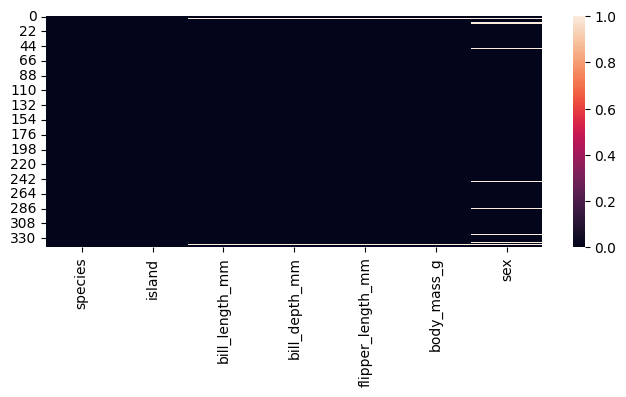

In [40]:
plt.figure(figsize=(8,3))
sns.heatmap( df.isnull() )
plt.show()

In [41]:
df['sex'] = df['sex'].ffill()

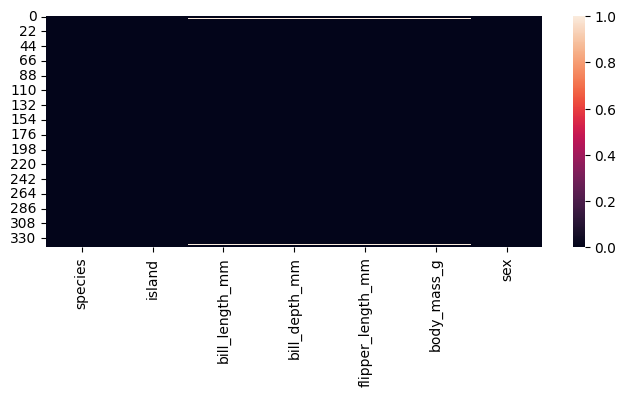

In [42]:
plt.figure(figsize=(8,3))
sns.heatmap( df.isnull() )
plt.show()

In [43]:
df = df.dropna()

In [44]:
df.shape

(342, 7)

In [45]:
df.isnull().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 342 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            342 non-null    object 
 1   island             342 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                342 non-null    object 
dtypes: float64(4), object(3)
memory usage: 21.4+ KB


In [47]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


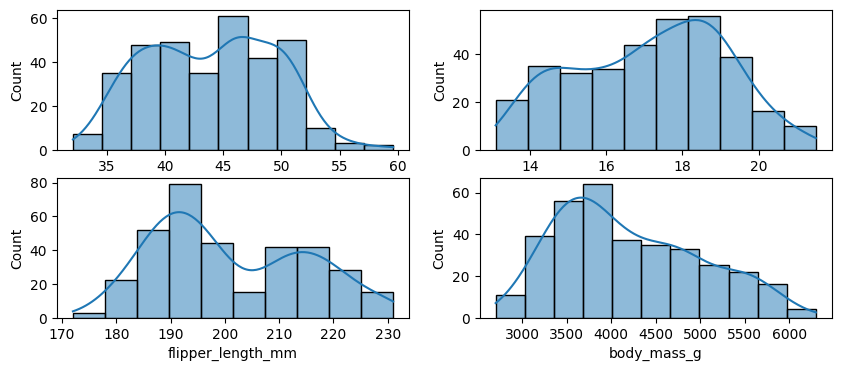

In [48]:
# Checking Outlier in Dataset
plt.figure( figsize=(10,4) )
i = 1
for col in df.select_dtypes(include=np.number).columns:
    plt.subplot(2,2,i)
    sns.histplot(x=col , data=df , kde=True)
    i = i+1
plt.show()

In [49]:
df.head(2)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female


In [30]:
# Encode "SPECIES" y (target) feature
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder(categories=[species])

In [32]:
df['species'] = encoder.fit_transform(df[['species']]) 

In [33]:
df.head(2)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,0.0,Torgersen,39.1,18.7,181.0,3750.0,Male
1,0.0,Torgersen,39.5,17.4,186.0,3800.0,Female


In [50]:
# Encoding in another way
df.head(2)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female


In [51]:
df['species'] = df['species'].map( lambda val: species.index(val))

In [52]:
df.head(2)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,0,Torgersen,39.1,18.7,181.0,3750.0,Male
1,0,Torgersen,39.5,17.4,186.0,3800.0,Female


In [53]:
# Divide Data into X(data) and y(feature)

In [54]:
X = df.drop(columns=['species'])
y = df['species']

In [55]:
X.head(2)

,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Torgersen,39.5,17.4,186.0,3800.0,Female


In [57]:
# Prepare X(data) for training
# ENCODING
from sklearn.preprocessing import LabelEncoder

In [58]:
encoder = LabelEncoder()

In [65]:
for col in X.select_dtypes(include=object).columns:
    X[col] = encoder.fit_transform(X[col])

In [66]:
X.head(2)

,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,2,39.1,18.7,181.0,3750.0,1
1,2,39.5,17.4,186.0,3800.0,0


In [68]:
# Scaling X(data) for model training
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [73]:
for col in X.select_dtypes(include=float).columns:
    X[col] = scaler.fit_transform(X[[col]])

In [74]:
X.head(3)

,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,2,0.254545,0.666667,0.152542,0.291667,1
1,2,0.269091,0.511905,0.237288,0.305556,0
2,2,0.298182,0.583333,0.389831,0.152778,0


In [75]:
# Divide data/target into train and testing
from sklearn.model_selection import train_test_split

In [76]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [78]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [79]:
models = {
    'Logistic Regression' : LogisticRegression(),
    'Support Vector Classifier' : SVC(),
    'Random Forest Classifier' : RandomForestClassifier(),
    'Decision Tree Classifier' : DecisionTreeClassifier()
}

In [80]:
from sklearn.metrics import accuracy_score

In [81]:
# Start Training and Model Evaluation
for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    print(f"Model : {name}\t Accuracy Score : {accuracy_score(y_test,y_pred)*100}")

Model : Logistic Regression	 Accuracy Score : 97.10144927536231
Model : Support Vector Classifier	 Accuracy Score : 100.0
Model : Random Forest Classifier	 Accuracy Score : 95.65217391304348
Model : Decision Tree Classifier	 Accuracy Score : 94.20289855072464
